<a href="https://colab.research.google.com/github/Rohanrathod7/my-ds-labs/blob/main/26_Introduction_to_Regression_with_statsmodels_in_Python/03_Assessing_model_fit_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import datetime as dt


In [5]:
import pandas as pd

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/26_Introduction_to_Regression_with_statsmodels_in_Python/dataset/taiwan_real_estate2.csv"
# Read the CSV file
taiwan_real_estate = pd.read_csv(url)
display(taiwan_real_estate.head())

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/26_Introduction_to_Regression_with_statsmodels_in_Python/dataset/sp500_yearly_returns.csv"
# Read the CSV file
sp500_yearly_returns = pd.read_csv(url)
display(sp500_yearly_returns.head())

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/26_Introduction_to_Regression_with_statsmodels_in_Python/dataset/ad_conversion.csv"
# Read the CSV file
ad_conversion = pd.read_csv(url)
display(ad_conversion.head())

,dist_to_mrt_m,n_convenience,house_age_years,price_twd_msq
0,84.87882,10,30 to 45,11.467474
1,306.59470,9,15 to 30,12.768533
2,561.98450,5,0 to 15,14.311649
3,561.98450,5,0 to 15,16.580938
4,390.56840,5,0 to 15,13.040847


,symbol,return_2018,return_2019
0,AAPL,-0.053902,0.889578
1,MSFT,0.207953,0.575581
2,AMZN,0.284317,0.230278
3,FB,-0.257112,0.565718
4,GOOGL,-0.008012,0.281762


,spent_usd,n_impressions,n_clicks
0,1.43,7350,1
1,1.82,17861,2
2,1.25,4259,1
3,1.29,4133,1
4,4.77,15615,3


In [8]:
# Import the ols function
from statsmodels.formula.api import ols

# Create the model object
mdl_price_vs_conv = ols('price_twd_msq ~ n_convenience', data=taiwan_real_estate)

# Fit the model
mdl_price_vs_conv = mdl_price_vs_conv.fit()

# Print the parameters of the fitted model
print(mdl_price_vs_conv.params)

Intercept        8.224237
n_convenience    0.798080
dtype: float64


**Coefficient of determination**
The coefficient of determination is a measure of how well the linear regression line fits the observed values. For simple linear regression, it is equal to the square of the correlation between the explanatory and response variables.

Here, you'll take another look at the second stage of the advertising pipeline: modeling the click response to impressions. Two models are available: mdl_click_vs_impression_orig models n_clicks versus n_impressions. mdl_click_vs_impression_trans is the transformed model you saw in Chapter 2. It models n_clicks to the power of 0.25 versus n_impressions to the power of 0.25.

In [11]:
ad_conversion["qdrt_n_impressions"] = ad_conversion["n_impressions"] ** 0.25
ad_conversion["qdrt_n_clicks"] = ad_conversion["n_clicks"] ** 0.25

# Create the original model
mdl_click_vs_impression_orig = ols("n_clicks ~ n_impressions", data=ad_conversion).fit()

# Create the transformed model
mdl_click_vs_impression_trans = ols("qdrt_n_clicks ~ qdrt_n_impressions", data=ad_conversion).fit()

explanatory_data = pd.DataFrame({"qdrt_n_impressions": np.arange(0, 3e6+1, 5e5) ** .25,
                                 "n_impressions": np.arange(0, 3e6+1, 5e5)})

# Complete prediction_data
prediction_data = explanatory_data.assign(
    qdrt_n_clicks = mdl_click_vs_impression_trans.predict(explanatory_data)
)

# Print the result
print(prediction_data)

# Since the response variable has been transformed, you'll now need to back-transform the predictions to correctly interpret your results.


# Print the coeff of determination for mdl_click_vs_impression_orig
print(mdl_click_vs_impression_orig.rsquared)

# Print the coeff of determination for mdl_click_vs_impression_trans
print(mdl_click_vs_impression_trans.rsquared)

   qdrt_n_impressions  n_impressions  qdrt_n_clicks
0            0.000000            0.0       0.071748
1           26.591479       500000.0       3.037576
2           31.622777      1000000.0       3.598732
3           34.996355      1500000.0       3.974998
4           37.606031      2000000.0       4.266063
5           39.763536      2500000.0       4.506696
6           41.617915      3000000.0       4.713520
0.8916134973508041
0.9445272817143905


**Residual standard error**  
Residual standard error (RSE) is a measure of the typical size of the residuals. Equivalently, it's a measure of how wrong you can expect predictions to be. Smaller numbers are better, with zero being a perfect fit to the data.

Again, you'll look at the models from the advertising pipeline, mdl_click_vs_impression_orig and mdl_click_vs_impression_trans.

In [12]:
# Calculate mse_orig for mdl_click_vs_impression_orig
mse_orig = mdl_click_vs_impression_orig.mse_resid

# Calculate rse_orig for mdl_click_vs_impression_orig and print it
rse_orig = np.sqrt(mdl_click_vs_impression_orig.mse_resid)
print("RSE of original model: ", rse_orig)

# Calculate mse_trans for mdl_click_vs_impression_trans
mse_trans = mdl_click_vs_impression_trans.mse_resid

# Calculate rse_trans for mdl_click_vs_impression_trans and print it
rse_trans = np.sqrt(mdl_click_vs_impression_trans.mse_resid)
print("RSE of transformed model: ", rse_trans)

RSE of original model:  19.905838862478138
RSE of transformed model:  0.19690640896875722


## Residuals vs. fitted values
Here you can see diagnostic plots of residuals versus fitted values for two models on advertising conversion.

Original model (n_clicks versus n_impressions):

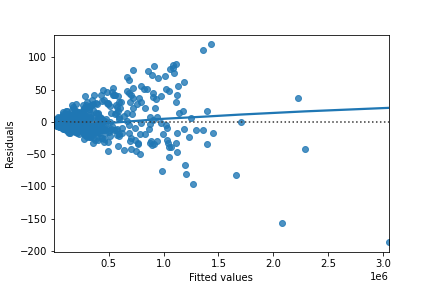

    Transformed model (n_clicks ** 0.25 versus n_impressions ** 0.25):

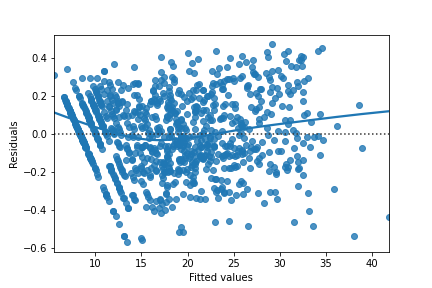

Look at the numbers on the y-axis scales and how well the trend lines follow the
 line. Which statement is true?


 - The residuals track the
 line more closely in the original model compared to the transformed model, indicating that the original model is a better fit for the data.


- The residuals track the
 line more closely in the transformed model compared to the original model, indicating that the original model is a better fit for the data.


- The residuals track the
 line more closely in the original model compared to the transformed model, indicating that the transformed model is a better fit for the data.


- --The residuals track the
 line more closely in the transformed model compared to the original model, indicating that the transformed model is a better fit for the data.

 [ a good model, the residuals should have a trend line close to zero. ]

## Q-Q plot of residuals
Here are normal Q-Q plots of the previous two models.

Original model (n_clicks versus n_impressions):

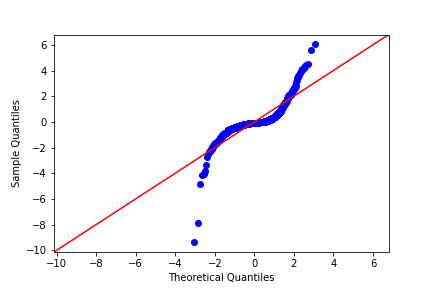

    Transformed model (n_clicks ** 0.25 versus n_impressions ** 0.25):

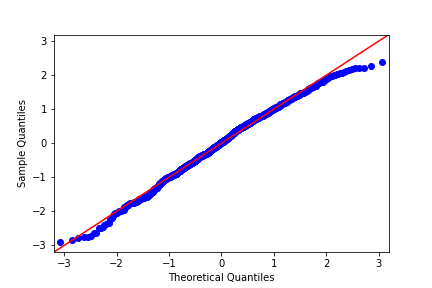

    Look at how well the points track the "normality" line. Which statement is true?

- The residuals track the "normality" line more closely in the original model compared to the transformed model, indicating that the original model is a better fit for the data.


- The residuals track the "normality" line more closely in the original model compared to the transformed model, indicating that the transformed model is a better fit for the data.


- --The residuals track the "normality" line more closely in the transformed model compared to the original model, indicating that the transformed model is a better fit for the data.


- The residuals track the "normality" line more closely in the transformed model compared to the original model, indicating that the original model is a better fit for the data.

[ If the residuals from the model are normally distributed, then the points will track the line on the Q-Q plot. In this case, neither model is perfect, but the transformed model is closer. ]

## Scale-location
Here are normal scale-location plots of the previous two models. That is, they show the size of residuals versus fitted values.

Original model (n_clicks versus n_impressions):
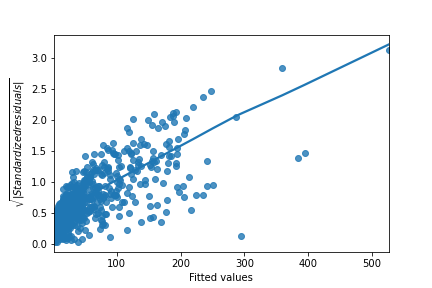


    Transformed model (n_clicks ** 0.25 versus n_impressions ** 0.25):

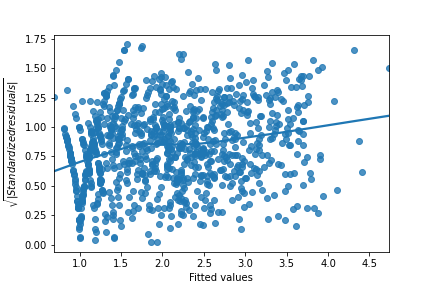

    Look at the numbers on the y-axis and the slope of the trend line. Which statement is true?

    
- The size of the standardized residuals is more consistent in the original model compared to the transformed model, indicating that the original model is a better fit for the data.


- --The size of the standardized residuals is more consistent in the transformed model compared to the original model, indicating that the transformed model is a better fit for the data.


- The size of the standardized residuals is more consistent in the transformed model compared to the original model, indicating that the original model is a better fit for the data.


- The size of the standardized residuals is more consistent in the original model compared to the transformed model, indicating that the transformed model is a better fit for the data.

[  In a good model, the size of the residuals shouldn't change much as the fitted values change. ]

**Drawing diagnostic plots**  
It's time for you to draw these diagnostic plots yourself using the Taiwan real estate dataset and the model of house prices versus number of convenience stores.

taiwan_real_estate is available as a pandas DataFrame and mdl_price_vs_conv is available.

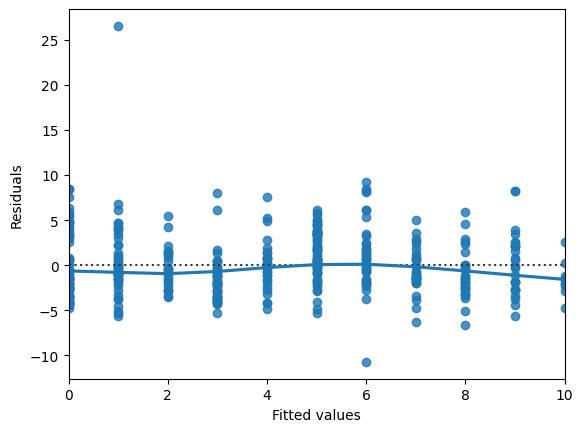

In [13]:
# Plot the residuals vs. fitted values
sns.residplot(x="n_convenience", y="price_twd_msq", data=taiwan_real_estate, lowess=True)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")

# Show the plot
plt.show()

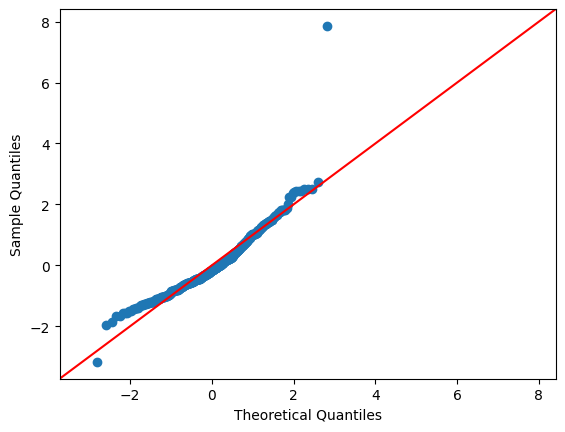

In [14]:
# Import qqplot
from statsmodels.api import qqplot

# Create the Q-Q plot of the residuals
qqplot(data=mdl_price_vs_conv.resid, fit=True, line="45")

# Show the plot
plt.show()

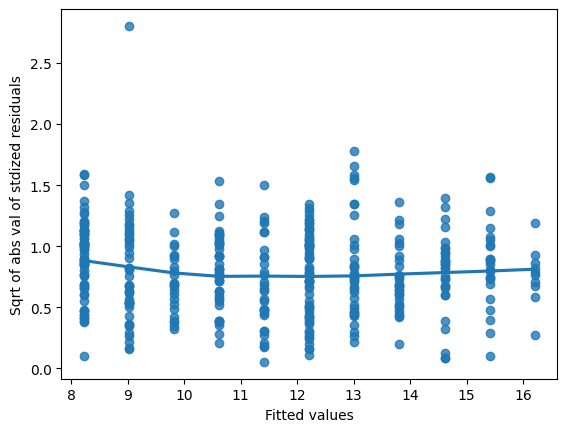

In [15]:
# Preprocessing steps
model_norm_residuals = mdl_price_vs_conv.get_influence().resid_studentized_internal
model_norm_residuals_abs_sqrt = np.sqrt(np.abs(model_norm_residuals))

# Create the scale-location plot
sns.regplot(x=mdl_price_vs_conv.fittedvalues, y=model_norm_residuals_abs_sqrt, ci=None, lowess=True)
plt.xlabel("Fitted values")
plt.ylabel("Sqrt of abs val of stdized residuals")

# Show the plot
plt.show()

### Leverage
Leverage measures how unusual or extreme the explanatory variables are for each observation. Very roughly, high leverage means that the explanatory variable has values that are different from other points in the dataset. In the case of simple linear regression, where there is only one explanatory value, this typically means values with a very high or very low explanatory value.

Here, you'll look at highly leveraged values in the model of house price versus the square root of distance from the nearest MRT station in the Taiwan real estate dataset.

Guess which observations you think will have a high leverage, then move the slider to find out.


Which statement is true?


- Observations with a large distance to the nearest MRT station have the highest leverage, because these points are furthest away from the linear regression trend line.

- Observations with a large distance to the nearest MRT station have the highest leverage, because leverage is proportional to the explanatory variable.

- --Observations with a large distance to the nearest MRT station have the highest leverage, because most of the observations have a short distance, so long distances are more extreme.

- Observations with a high price have the highest leverage, because most of the observations have a low price, so high prices are most extreme.

**Influence**  
Influence measures how much a model would change if each observation was left out of the model calculations, one at a time. That is, it measures how different the prediction line would look if you would run a linear regression on all data points except that point, compared to running a linear regression on the whole dataset.

The standard metric for influence is Cook's distance, which calculates influence based on the residual size and the leverage of the point.

You can see the same model as last time: house price versus the square root of distance from the nearest MRT station in the Taiwan real estate dataset.

Guess which observations you think will have a high influence, then move the slider to find out.

Which statement is true?

- ==Observations far away from the trend line have high influence, because they have large residuals and are far away from other observations.

- Observations with high prices have high influence, because influence is proportional to the response variable.

- Observations far away from the trend line have high influence, because the slope of the trend is negative.

- Observations far away from the trend line have high influence, because that increases the leverage of those points.

[ The majority of the influential houses were those with prices that were much higher than the model predicted (and one with a price that was much lower). ]

**Extracting leverage and influence**  
In the last few exercises, you explored which observations had the highest leverage and influence. Now you'll extract those values from the model.

mdl_price_vs_dist and taiwan_real_estate are available.

In [18]:
# Create the model of price vs. square root of distance to MRT
mdl_price_vs_dist = ols("price_twd_msq ~ dist_to_mrt_m", data=taiwan_real_estate).fit()

# Create summary_info
summary_info = mdl_price_vs_dist.get_influence().summary_frame()

# Add the hat_diag column to taiwan_real_estate, name it leverage
taiwan_real_estate["leverage"] = summary_info["hat_diag"]

# Add the cooks_d column to taiwan_real_estate, name it cooks_dist
taiwan_real_estate["cooks_dist"] = summary_info["cooks_d"]

# Sort taiwan_real_estate by cooks_dist in descending order and print the head.
print(taiwan_real_estate.sort_values("cooks_dist", ascending=False).head())

# Leverage and influence are important concepts for determining whether your model is overly affected by some unusual data points.

     dist_to_mrt_m  n_convenience house_age_years  price_twd_msq  leverage  \
270       252.5822              1         0 to 15      35.552194  0.003466   
249      6306.1530              1        15 to 30       4.538578  0.043870   
148      3780.5900              0        15 to 30      13.645991  0.013470   
116      6396.2830              1        30 to 45       3.691377  0.045313   
347      6488.0210              1        15 to 30       3.388805  0.046808   

     cooks_dist  
270    0.092948  
249    0.052859  
148    0.048675  
116    0.040168  
347    0.039480  
